<b><font size="10">Project - <i>"Where Should I Live?"</i></font></b><a class="anchor"></a><a id="toc"></a><br>


## <font color='#0EE071'>Table of Contents</font> <a class="anchor" id='toc'></a>

- [1. Data Importation](#1)
  - [1.1 Import CSV](#1_1)
  - [1.2 Separate Columns](#1_2)
  - [1.3 Update Index](#1_3)
  - [1.4 Change Datatypes](#1_4)
- [3. Data Wrangling and Analysis](#3)
  - [3.1 Analysis Results and Key Insights ](#3_1)
- [4. Advanced Topic - Building an Interactive Map](#4)
   - [4.1 Web Scraping](#4_1)
   - [4.2 Interactive Map](#4_2)
- [5. Data Science In Action](#5)
   - [5.1 Recomendation System](#5_1)

### <font color='#0EE071'>1. Data Importation </font> <a class="anchor" id="1"></a>
  [Back to TOC](#toc)

In [1]:
import os
import re
import subprocess
import threading
import time
import warnings
import webbrowser
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from sklearn.impute import KNNImputer
from selenium import webdriver
from selenium.common.exceptions import TimeoutException, WebDriverException
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait

warnings.filterwarnings('ignore')

In [2]:
C_PRIMARY    = '#2E86C1'
C_SECONDARY  = '#A23B72'
C_POSITIVE   = '#00D2D3'
C_NEGATIVE   = '#FF6B6B'
C_LIGHT_GREY = '#F8F9FA'

#### IMPORT CSV<a class="anchor" id="1_1"></a>

In [3]:
dataframe = pd.read_csv('city_data.csv', sep = '|', skiprows=1)
dataframe.head()

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
4,"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00


#### SEPARATE COLUMNS, RENAME AND ORGANIZE THEM<a class="anchor" id="1_2"></a>

In [4]:
#dataframe['City'].tolist()

In [5]:
dataframe['City'] = dataframe['City'].replace({'Greece, Athens': 'Athens, Greece'})

In [6]:
dataframe['City'] = dataframe['City'].str.replace(';', ',')
dataframe['City'] = dataframe['City'].str.replace('.', ',') 
dataframe[['City', 'Country']] = dataframe['City'].str.rsplit(',', n=1, expand=True)
dataframe['City'] = dataframe['City'].str.strip()
dataframe['Country'] = dataframe['Country'].str.strip()

In [7]:
dataframe['City'] = dataframe['City'].replace('Frankfurt am Main', 'Frankfurt') #to make it easier to read

In [8]:
#dataframe.columns

In [9]:
dataframe = dataframe.rename(columns={'Avgerage Rent Price': 'Average Rent Price',
                                      'Working Age Population ': 'Working Age Population'})

In [10]:
columns_order = ['City','Country','Population Density','Population','Working Age Population','Youth Dependency Ratio','Unemployment Rate',
                 'GDP per Capita','Days of very strong heat stress','Main Spoken Languages','Average Monthly Salary','Average Rent Price',
                 'Average Cost of Living','Average Price Groceries','Last Data Update']
df = dataframe[columns_order]

#### UPDATE INDEX<a class="anchor" id="1_3"></a>

As we want to study cities, we should define 'City' as our Index (if it is unique).

In [11]:
df['City'].duplicated().sum()

np.int64(2)

In [12]:
df[df['City'].duplicated(keep=False)]

,City,Country,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
15,Berlin,Germany,304.0,5303922,3481212.0,21.3,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
16,Berlin,Germany,304.0,5303922,3481212.0,21.3,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
32,Malaga,Spain,571.0,869096,585608.0,23.5,17.7,27694.0,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00
33,Malaga,Spain,571.0,869096,585608.0,23.5,17.7,27694.0,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00


In [13]:
df = df.drop([16, 33], axis=0)

In [14]:
#df['City'].duplicated().sum()

In [15]:
df = df.set_index('City')

#### CHANGE DATATYPES<a class="anchor" id="1_4"></a>

In [16]:
df.dtypes

Country                             object
Population Density                 float64
Population                           int64
Working Age Population             float64
Youth Dependency Ratio             float64
Unemployment Rate                  float64
GDP per Capita                     float64
Days of very strong heat stress      int64
Main Spoken Languages               object
Average Monthly Salary               int64
Average Rent Price                   int64
Average Cost of Living               int64
Average Price Groceries            float64
Last Data Update                    object
dtype: object

In [17]:
numeric_cols = ['Population Density','Population','Working Age Population','Youth Dependency Ratio','Unemployment Rate','GDP per Capita',
                'Days of very strong heat stress','Average Monthly Salary','Average Rent Price','Average Cost of Living','Average Price Groceries']

In [18]:
for col in numeric_cols:
    if col in df.columns:
        min_val = df[col].min()
        max_val = df[col].max()
        current_dtype = df[col].dtype
        
        print(f" {col} - Min: {min_val}, Max: {max_val}, Type: {current_dtype}")

 Population Density - Min: 65.0, Max: 20983.0, Type: float64
 Population - Min: 73895, Max: 12396541, Type: int64
 Working Age Population - Min: 46359.0, Max: 8274794.0, Type: float64
 Youth Dependency Ratio - Min: 19.3, Max: 37.8, Type: float64
 Unemployment Rate - Min: 1.4, Max: 23.0, Type: float64
 GDP per Capita - Min: 10089.92, Max: 146094.0, Type: float64
 Days of very strong heat stress - Min: 0, Max: 59, Type: int64
 Average Monthly Salary - Min: 750, Max: 6636, Type: int64
 Average Rent Price - Min: 100, Max: 3190, Type: int64
 Average Cost of Living - Min: 800, Max: 4862, Type: int64
 Average Price Groceries - Min: 100.0, Max: 340.0, Type: float64


- CHANGE `int64` TO CORRECT INT TYPES

In [19]:
#df['Population'] = df['Population'].astype('int32')
#df['Days of very strong heat stress'] = df['Days of very strong heat stress'].astype('int8')
#df['Average Monthly Salary'] = df['Average Monthly Salary'].astype('int16')
#df['Average Rent Price'] = df['Average Rent Price'].astype('int16')
#df['Average Cost of Living'] = df['Average Cost of Living'].astype('int16')

- CHANGE `float64` TO CORRECT FLOAT TYPES

In [20]:
#df['Population Density'] = df['Population Density'].astype('float32')
#df['Working Age Population'] = df['Working Age Population'].astype('float32')
#df['Youth Dependency Ratio'] = df['Youth Dependency Ratio'].astype('float32')
#df['Unemployment Rate'] = df['Unemployment Rate'].astype('float32')
#df['GDP per Capita'] = df['GDP per Capita'].astype('float32')
#df['Average Price Groceries'] = df['Average Price Groceries'].astype('float16')

- CHANGE `object` TO `category`

In [21]:
#country = df['Country']
#print(f'There are {country.nunique()} countries in the Dataset.')
#country.unique()

In [22]:
#df['City'] = df['City'].astype('category') - City is the index, so we don´t need to change the type.
#df['Country'] = df['Country'].astype('category')

- CHANGE `Last Data Update` TO `datatime`

In [23]:
df['Last Data Update'] = pd.to_datetime(df['Last Data Update'], errors='coerce')

### <font color='#0EE071'>3. Data Wrangling and Analysis </font> <a class="anchor" id="3"></a>
  [Back to TOC](#toc)

#### **Analysis Results and Key Insights** <a class="anchor" id="3_1"></a>

#### **1.**
---

How did you handle missing values and duplicate records in the dataset?
Justify your approach.

> Handling missing values

In [24]:
df.isnull().sum()

Country                             0
Population Density                  1
Population                          0
Working Age Population              1
Youth Dependency Ratio              0
Unemployment Rate                   1
GDP per Capita                      1
Days of very strong heat stress     0
Main Spoken Languages               1
Average Monthly Salary              0
Average Rent Price                  0
Average Cost of Living              0
Average Price Groceries            78
Last Data Update                    0
dtype: int64

In [25]:
#df.info()

In [26]:
df.drop('Average Price Groceries', axis=1, inplace=True)

The column `Average Price Groceries` was dropped as it contained 78 null values out of 84 (93% missing), providing negligible analytical value and risking skewed processing without viable imputation.

- INPUT NULL IN `Population Density` 

In [27]:
df[df['Population Density'].isna()]

,Country,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
City,,,,,,,,,,,,,
Valencia,Spain,NaN,1748142,1162828.0,22.6,13.7,33570.0,5,Spanish;Valencian,2400,1190,1300,2023-06-04


Mean: 923.0
Median: 722.0


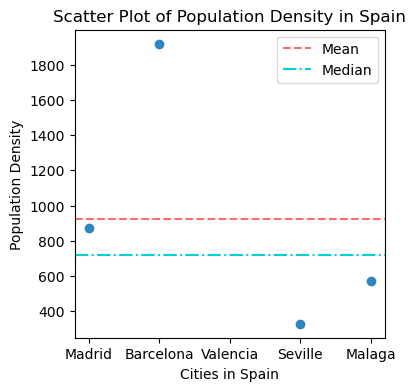

In [28]:
population_density_spain = df[df['Country'] == 'Spain']['Population Density']

mean_density = population_density_spain.mean()
median_density = population_density_spain.median()

print(f'Mean: {mean_density}')
print(f'Median: {median_density}')

x_vals = population_density_spain.index

plt.figure(figsize=(4, 4))
plt.scatter(x_vals, population_density_spain, color=C_PRIMARY)
plt.title('Scatter Plot of Population Density in Spain')
plt.xlabel('Cities in Spain')
plt.ylabel('Population Density')
plt.axhline(y=mean_density, color=C_NEGATIVE, linestyle='--', label='Mean')
plt.axhline(y=median_density, color=C_POSITIVE, linestyle='-.', label='Median')
plt.legend()

plt.show()

In [29]:
df.loc['Valencia', 'Population Density'] = median_density

- INPUT NULL IN `Working Age Population` 

In [30]:
df[df['Working Age Population'].isna()]

,Country,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
City,,,,,,,,,,,,,
Dusseldorf,Germany,1295.0,1554077,NaN,21.4,3.3,71238.0,3,NaN,3200,1100,2050,2024-01-15


Mean Age Population Ratio: 0.6521053338475745
Median Age Population Ratio: 0.6581699263597741


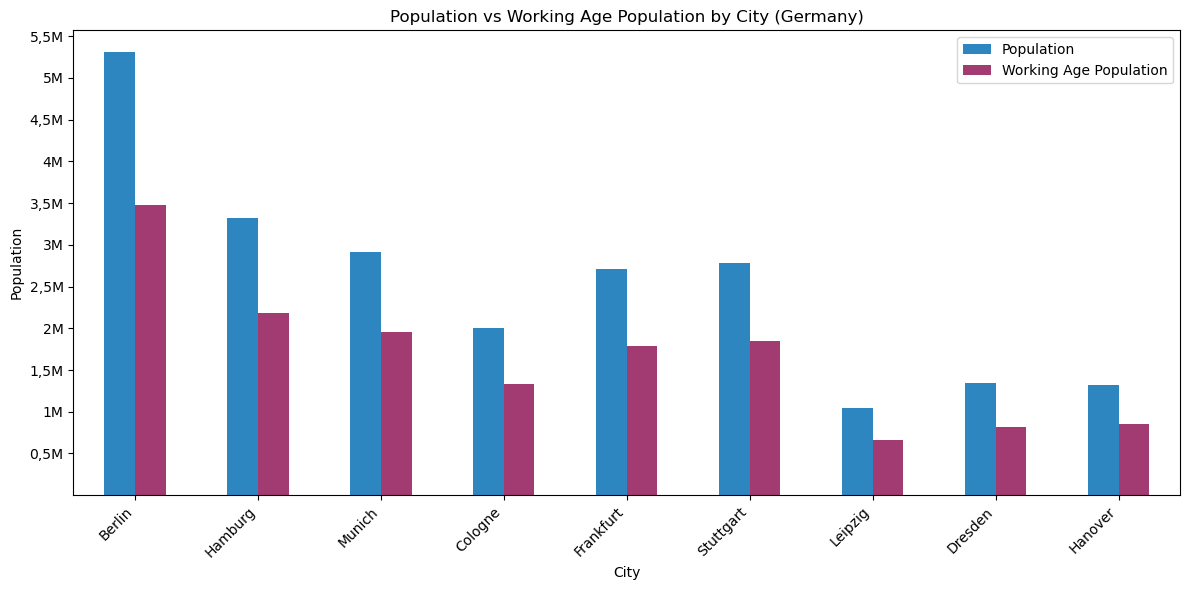

In [31]:
df_germany = df.loc[df['Country'] == 'Germany'].copy()
df_germany['Age_Pop_Ratio'] = df_germany['Working Age Population'] / df_germany['Population']
df_germany = df_germany.dropna(subset=['Age_Pop_Ratio'])

mean_ratio = df_germany['Age_Pop_Ratio'].mean()
median_ratio = df_germany['Age_Pop_Ratio'].median()
print(f"Mean Age Population Ratio: {mean_ratio}")
print(f"Median Age Population Ratio: {median_ratio}")

df_germany[['Population', 'Working Age Population']].plot.bar(figsize=(12,6),color=[C_PRIMARY, C_SECONDARY])
plt.title('Population vs Working Age Population by City (Germany)')
plt.ylabel('Population')
plt.xticks(rotation=45, ha='right')
plt.yticks([500000,1000000,1500000,2000000,2500000,3000000,3500000,4000000,4500000,5000000,5500000],
           ['0,5M','1M', '1,5M', '2M','2,5M','3M','3,5M','4M','4,5M','5M','5,5M'])
plt.tight_layout()

plt.show()

In [32]:
df.loc['Dusseldorf', 'Working Age Population'] = median_ratio * df.loc['Dusseldorf', 'Population']

- INPUT NULL IN `Unemployment Rate` 

In [33]:
df[df['Unemployment Rate'].isna()]

,Country,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
City,,,,,,,,,,,,,
Gent,Belgium,552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,2023-07-17


Mean: 7.5
Median: 6.2


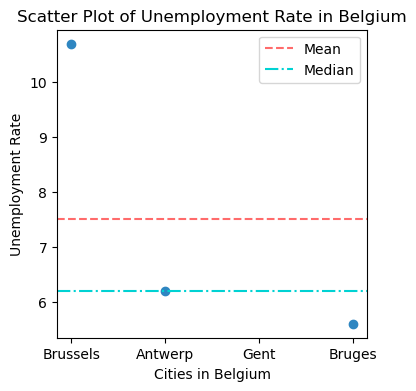

In [34]:
unemployment_rate_belgium = df[df['Country'] == 'Belgium']['Unemployment Rate']

mean_rate = unemployment_rate_belgium.mean()
median_rate = unemployment_rate_belgium.median()

print(f'Mean: {mean_rate}')
print(f'Median: {median_rate}')

x_vals = unemployment_rate_belgium.index

plt.figure(figsize=(4, 4))
plt.scatter(x_vals, unemployment_rate_belgium, color=C_PRIMARY)
plt.title('Scatter Plot of Unemployment Rate in Belgium')
plt.xlabel('Cities in Belgium')
plt.ylabel('Unemployment Rate')
plt.axhline(y=mean_rate, color=C_NEGATIVE, linestyle='--', label='Mean')
plt.axhline(y=median_rate, color=C_POSITIVE, linestyle='-.', label='Median')
plt.legend()

plt.show()

In [35]:
df.loc['Gent', 'Unemployment Rate'] = median_rate

- INPUT NULL IN `GDP per Capita` 

In [36]:
df[df['GDP per Capita'].isna()]

,Country,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
City,,,,,,,,,,,,,
Lemesos,Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14


In [37]:
gdp_cyprus = df[df['Country'] == 'Cyprus']['GDP per Capita']

mean_gdp = gdp_cyprus.mean()
median_gdp = gdp_cyprus.median()

print(f'Mean: {mean_gdp}')
print(f'Median: {median_gdp}')

Mean: 34907.0
Median: 34907.0


In [38]:
df.loc['Lemesos', 'GDP per Capita'] = mean_gdp

- INPUT NULL IN `Main Spoken Languages` 

In [39]:
df[df['Main Spoken Languages'].isna()]

,Country,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
City,,,,,,,,,,,,,
Dusseldorf,Germany,1295.0,1554077,1.022847e+06,21.4,3.3,71238.0,3,NaN,3200,1100,2050,2024-01-15


In [40]:
df_germany_temp = df.loc[df['Country'] == 'Germany'].copy()
df_germany_temp = df_germany_temp.dropna(subset=['Main Spoken Languages'])
df_germany_temp['Languages_List'] = df_germany_temp['Main Spoken Languages'].str.split(',')
df_germany_exploded = df_germany_temp.explode('Languages_List')
df_germany_exploded['Languages_List'] = df_germany_exploded['Languages_List'].str.strip()

germany_language_counts = df_germany_exploded['Languages_List'].value_counts()
germany_languages_df = pd.DataFrame({
    'Language': germany_language_counts.index,
    'Frequence': germany_language_counts.values
})

germany_languages_df

,Language,Frequence
0,German,9
1,English,5
2,Turkish,4
3,Arabic,1


In [41]:
most_common_language = germany_language_counts.index[0]
df.loc['Dusseldorf', 'Main Spoken Languages'] = most_common_language

In [42]:
#df.isnull().sum()

> Handling Duplicates

We already handle duplicates above, droping the lines duplicated by their index with the following code:

```python
df['City'].duplicated().sum()
df[df['City'].duplicated(keep=False)] #to see both lines (not just one of each)
df = df.drop([16, 33], axis=0)

Since the duplicated entries had identical values across all columns, they were considered redundant. Removing them (df.drop([16, 33], axis=0)) prevents artificial inflation of counts for these cities/countries and ensures statistical calculations are accurate.

#### **2. a)**


---
Which country appears most frequently in the dataset? How many cities are
associated withits?

In [43]:
country_counts = df['Country'].value_counts()
print(f"Most frequent country: {country_counts.index[0]}")
print(f"Number of cities: {country_counts.values[0]}")

Most frequent country: Germany
Number of cities: 10


#### **2. b)**


---
How many cities are present in total? How many are associated with
Greece?

In [44]:
print(f"Total number of cities in dataset: {len(df)}")
print(f"Number of cities in Greece: {len(df[df['Country'] == 'Greece'])}")

Total number of cities in dataset: 84
Number of cities in Greece: 2


#### **2. c)**


---
Which is the least spoken language in the dataset? Which are the top 3 most
spoken languages?

In [45]:
df['Main Spoken Languages List'] = df['Main Spoken Languages'].str.split(',')
df_exploded = df.explode('Main Spoken Languages List')
df_exploded['Main Spoken Languages List'] = df_exploded['Main Spoken Languages List'].str.strip()

language_counts = df_exploded['Main Spoken Languages List'].value_counts()

print(f"Language: {language_counts.index[-1]}")
print(f"Frequency: {language_counts.values[-1]} city/cities")

Language: Slovene
Frequency: 1 city/cities


In [46]:
top_3_languages = language_counts.head(3)
top_3_languages

Main Spoken Languages List
English    46
German     15
Turkish    10
Name: count, dtype: int64

#### **3. a)**


---
Entries uploaded before April 2023 need to be updated. Which cities would 
require an update?

In [47]:
april_date = pd.to_datetime('2023-04-01')
update = df[df['Last Data Update'] < april_date]

print("Cities requiring update:")
print(update[['Country', 'Last Data Update']].sort_values('Last Data Update').to_string(index=True))

Cities requiring update:
                Country Last Data Update
City                                    
Basel       Switzerland       2023-01-19
Frankfurt       Germany       2023-02-04
Gothenburg       Sweden       2023-03-10
Munich          Germany       2023-03-16
Venice            Italy       2023-03-23
Lyon             France       2023-03-31


#### **3. b)**


---
How many days ago was the last update? On what day, month, and year did it occur?

In [48]:
most_recent_update = df['Last Data Update'].max()
current_date = datetime.now()
days_since_update = (current_date - most_recent_update).days

In [49]:
print(f"The last update was {days_since_update} days ago.")
print(f"Most recent update date: {most_recent_update.strftime('%d-%m-%Y')}")
print(f"Day: {most_recent_update.strftime('%A')}, {most_recent_update.strftime('%d')}")
print(f"Month: {most_recent_update.strftime('%B')}")
print(f"Year: {most_recent_update.year}")

The last update was 370 days ago.
Most recent update date: 12-12-2024
Day: Thursday, 12
Month: December
Year: 2024


#### **4. a)**


---
How are the Unemployment Rate and GDP per Capita distributed and 
related? What does this relationship suggest?
Provide a visual representation.

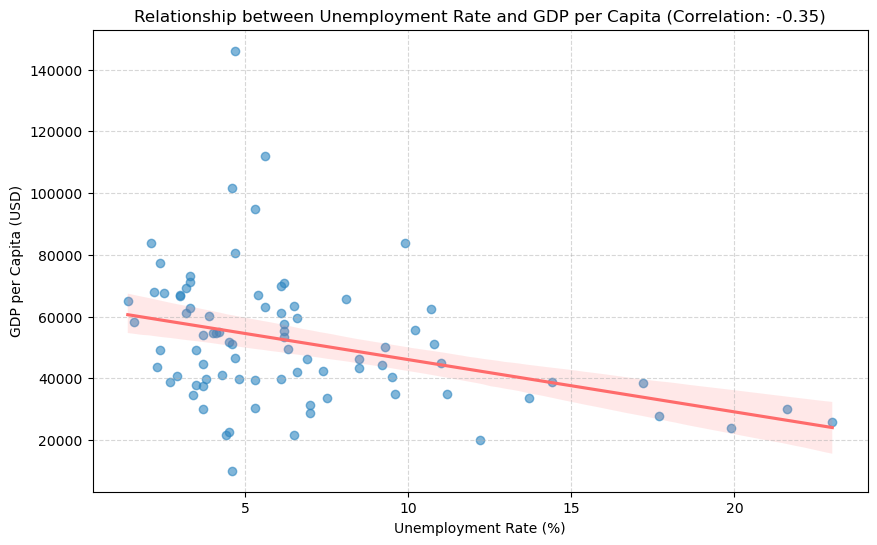

Correlation Coefficient (r): -0.35
Relationship Suggestion: This suggests a **negative correlation**. Generally, as the GDP per Capita (economic output) increases, the Unemployment Rate tends to decrease.


In [50]:
correlation = df['Unemployment Rate'].corr(df['GDP per Capita'])

plt.figure(figsize=(10, 6))
sns.regplot(x='Unemployment Rate', y='GDP per Capita', data=df, 
            scatter_kws={'alpha':0.6, 'color': C_PRIMARY}, 
            line_kws={'color': C_NEGATIVE})
plt.title(f'Relationship between Unemployment Rate and GDP per Capita (Correlation: {correlation:.2f})')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('GDP per Capita (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Correlation Coefficient (r): {correlation:.2f}")

if correlation < 0:
    suggestion = "This suggests a **negative correlation**. Generally, as the GDP per Capita (economic output) increases, the Unemployment Rate tends to decrease."
elif correlation > 0:
    suggestion = "This suggests a **positive correlation**. This is an unexpected finding, meaning both GDP per Capita and Unemployment Rate tend to increase or decrease together."
else:
    suggestion = "This suggests **no strong linear correlation** between the two variables."
    
print(f"Relationship Suggestion: {suggestion}")

#### **4. b)**


---
Which are the top 5 cities with the largest difference between the Average 
Monthly Salary and Average Cost of Living?
What about the top 5 countries with the smallest average difference?
Show these results with meaningful visualizations.

In [51]:
df['Salary_vs_CostLiv_Diff'] = abs(df['Average Monthly Salary'] - df['Average Cost of Living'])

In [52]:
top_5_l = df.nlargest(5, 'Salary_vs_CostLiv_Diff')[['Country', 'Average Monthly Salary', 'Average Cost of Living', 'Salary_vs_CostLiv_Diff']
]

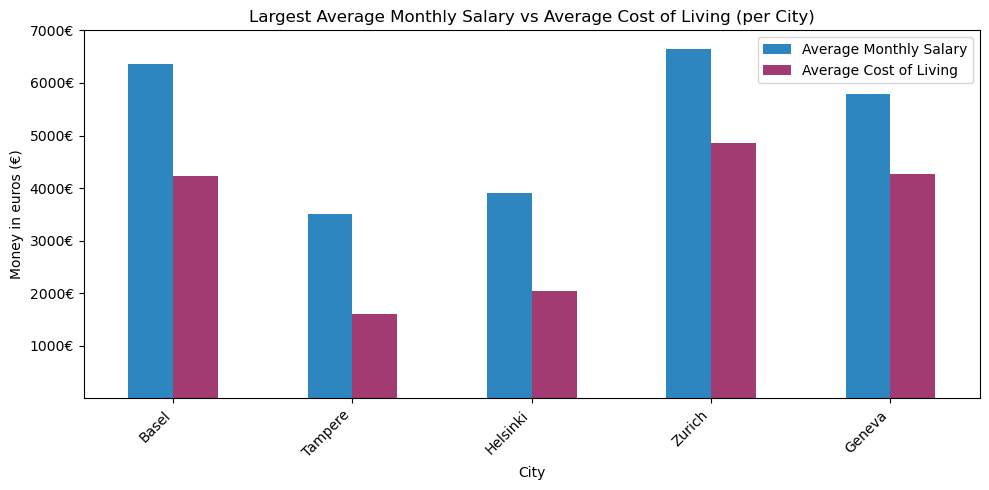

In [53]:
top_5_l[['Average Monthly Salary', 'Average Cost of Living']].plot.bar(figsize=(10,5),color=[C_PRIMARY, C_SECONDARY]) # Cores atualizadas
plt.title('Largest Average Monthly Salary vs Average Cost of Living (per City)')
plt.ylabel('Money in euros (€)')
plt.xticks(rotation=45, ha='right')
plt.yticks([1000,2000,3000,4000,5000,6000,7000],
           ['1000€','2000€','3000€','4000€','5000€','6000€','7000€'])
plt.tight_layout()

plt.show()

In [54]:
country_avg = df.groupby('Country').agg({
    'Salary_vs_CostLiv_Diff': 'mean',
    'Average Monthly Salary': 'mean',
    'Average Cost of Living': 'mean'
}).sort_values(by='Salary_vs_CostLiv_Diff')

In [55]:
top_5 = country_avg.head(5)

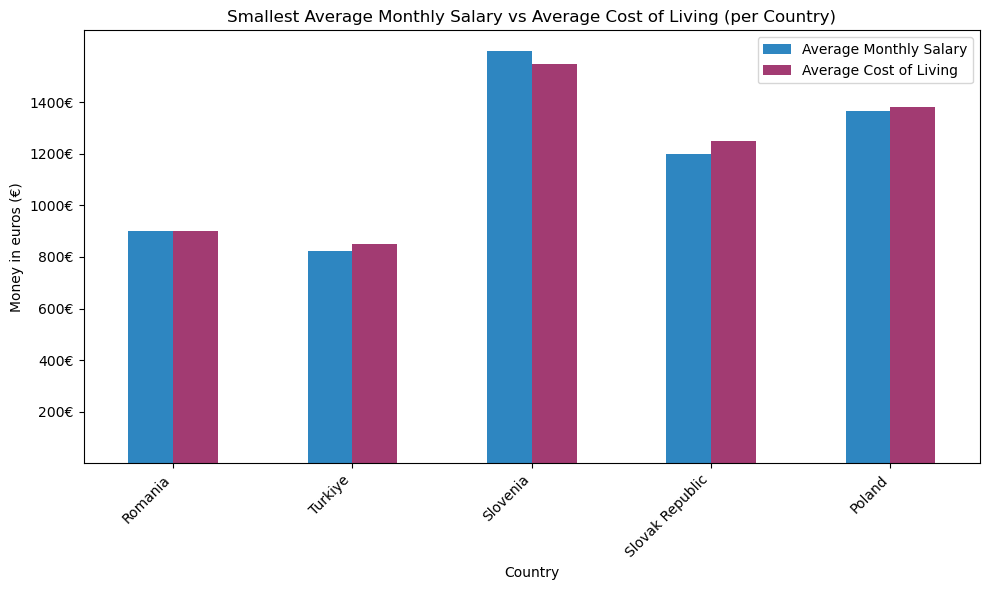

In [56]:
top_5[['Average Monthly Salary', 'Average Cost of Living']].plot.bar(figsize=(10,6), color=[C_PRIMARY, C_SECONDARY])
plt.title('Smallest Average Monthly Salary vs Average Cost of Living (per Country)')
plt.ylabel('Money in euros (€)')
plt.xticks(rotation=45, ha='right')
plt.yticks([200,400,600,800,1000,1200,1400],
           ['200€','400€','600€','800€','1000€','1200€','1400€'])
plt.tight_layout()

plt.show()

#### **4. c)**


---
Which is the best city for someone seeking: an average monthly salary above €2000, a cost of living below or equal to €1600, and with the lowest unemployment rate possible?


In [57]:
best_city_candidates = df[
    (df['Average Monthly Salary'] > 2000) &
    (df['Average Cost of Living'] <= 1600)
]

if not len(best_city_candidates)==0:
    best_city_by_unemployment = best_city_candidates.sort_values(by='Unemployment Rate').iloc[0]
    
    print(f"The best city for that criteria is: {best_city_by_unemployment.name}, {best_city_by_unemployment['Country']}")
else:
    print("No city simultaneously meets the criteria of Salary > €2000 and Cost of Living <= €1600.")

The best city for that criteria is: Dresden, Germany


#### **5.**


---
What are three additional insights you find meaningful when comparing the given cities?

> Rent Burden

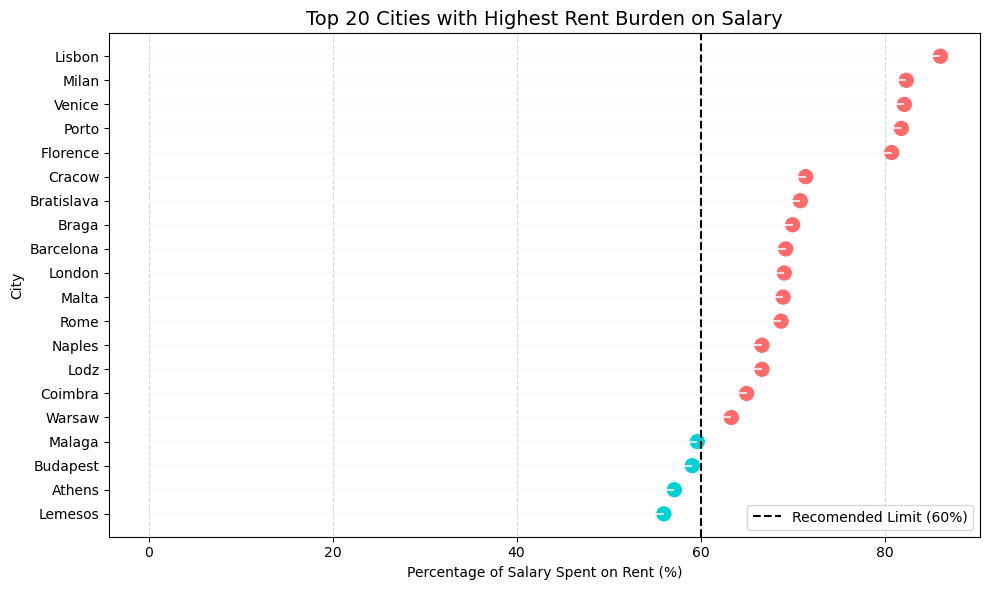

In [58]:
df['Rent_Burden'] = (df['Average Rent Price'] / df['Average Monthly Salary']) * 100
top_burden = df.nlargest(20, 'Rent_Burden').sort_values(by='Rent_Burden', ascending=True)

plt.figure(figsize=(10, 6))
plt.hlines(y=top_burden.index, xmin=0, xmax=top_burden['Rent_Burden'], color=C_LIGHT_GREY, alpha=0.8)
colors = [C_NEGATIVE if x > 60 else C_POSITIVE for x in top_burden['Rent_Burden']]
plt.scatter(top_burden['Rent_Burden'], top_burden.index, color=colors, s=100, alpha=1)
plt.axvline(x=60, color='black', linestyle='--', label='Recomended Limit (60%)')
plt.title('Top 20 Cities with Highest Rent Burden on Salary', fontsize=14)
plt.xlabel('Percentage of Salary Spent on Rent (%)')
plt.ylabel('City')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

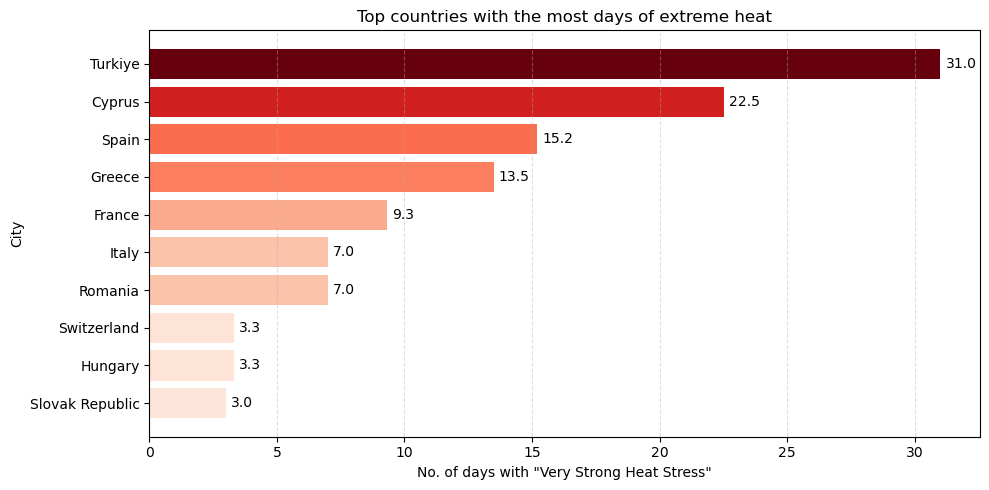

In [59]:
heat_stress = df.groupby('Country')['Days of very strong heat stress'].mean().sort_values()
heat_stress_top = heat_stress.tail(10)

plt.figure(figsize=(10, 5))
colors = plt.cm.Reds(heat_stress_top.values / heat_stress_top.max())
bars = plt.barh(heat_stress_top.index, heat_stress_top.values, color=colors)
plt.title('Top countries with the most days of extreme heat')
plt.xlabel('No. of days with "Very Strong Heat Stress"')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.4)

for bar in bars:
    width = round(bar.get_width(),1)
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{width:}', va='center')

plt.tight_layout()
plt.show()

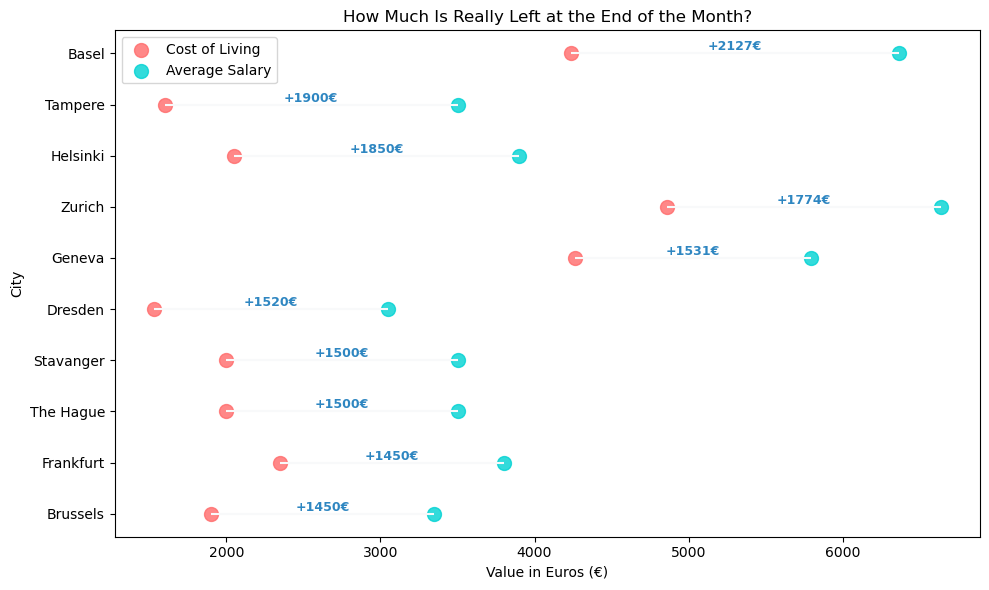

In [82]:
df['Disposable_Income'] = df['Average Monthly Salary'] - df['Average Cost of Living']
top_cities = df.nlargest(10, 'Disposable_Income').sort_values(by='Disposable_Income', ascending=True)

plt.figure(figsize=(10, 6))
plt.hlines(y=top_cities.index, xmin=top_cities['Average Cost of Living'], xmax=top_cities['Average Monthly Salary'], color=C_LIGHT_GREY, alpha=1)
plt.scatter(top_cities['Average Cost of Living'], top_cities.index, color=C_NEGATIVE, label='Cost of Living', s=100, alpha=0.8)
plt.scatter(top_cities['Average Monthly Salary'], top_cities.index, color=C_POSITIVE, label='Average Salary', s=100, alpha=0.8)

for i, (cost, salary) in enumerate(zip(top_cities['Average Cost of Living'], top_cities['Average Monthly Salary'])):
    diff = round(salary - cost, 0)
    plt.text((cost + salary)/2, i, f'+{diff:}€', va='bottom', ha='center', fontsize=9, color=C_PRIMARY, fontweight='bold')

plt.title('How Much Is Really Left at the End of the Month?')
plt.xlabel('Value in Euros (€)')
plt.ylabel('City')
plt.legend()
plt.tight_layout()
plt.show()

### <font color='#0EE071'>4. Advanced Topic - Building an Interactive Map </font> <a class="anchor" id="4"></a>
  [Back to TOC](#toc) 

#### **1. Web Scraping** <a class="anchor" id="4_1"></a>


---

In [61]:
def get_raw_string_by_search(driver, city, country):
    try:
        driver.get("https://en.wikipedia.org/wiki/Main_Page")
        driver.maximize_window()
        WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.ID, "mp-topbanner")))
        search_box = WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.ID, "searchInput")))
        query = f"{city}"
        search_box.clear()
        search_box.send_keys(query)
        driver.execute_script("document.getElementById('searchform').submit();")
        try:
            WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.ID, "firstHeading")))
        except Exception:
            print(f"[PAGE] Error: {city}, {country}")
            return None
        cur = driver.current_url
        html = driver.page_source
        soup = BeautifulSoup(html, "html.parser")
        geo_tag = soup.find("span", {"class": "geo"})
        if geo_tag and geo_tag.text.strip():
            coords = geo_tag.text.strip()
            return coords
        print(f"[COORD] Error: {city}, {country}")
        return None
    except Exception as e:
        print(f"[ERROR] {city} (Country: {country})")
        return None

raw_data_list = []

driver = webdriver.Chrome()
driver.maximize_window()

try:
    for city_name, row in df.iterrows():
        country_name = row["Country"]
        raw_text = get_raw_string_by_search(driver, city_name, country_name)
        raw_data_list.append(raw_text)
        if not raw_text:
            try:
                current_url = driver.current_url
            except WebDriverException:
                current_url = "N/A"
            print(f"Coordinates not found for city: {city_name} ")
        time.sleep(0.2)

finally:
    driver.quit()

df["Raw_Coordinates"] = raw_data_list

[COORD] Error: Gent, Belgium
Coordinates not found for city: Gent 
[COORD] Error: Split, Croatia
Coordinates not found for city: Split 
[COORD] Error: Cork, Ireland
Coordinates not found for city: Cork 


In [62]:
wiki_fix = {
    "Gent": "Ghent",
    "Cork": "Cork (city)",
    "Split": "Split, Croatia",
}

def get_raw_string_by_search(driver, city):
    try:
        driver.get("https://en.wikipedia.org/wiki/Main_Page")
        driver.maximize_window()
        WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.ID, "mp-topbanner")))
        search_box = WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.ID, "searchInput")))
        query = city
        search_box.clear()
        search_box.send_keys(query)
        driver.execute_script("document.getElementById('searchform').submit();")
        try:
            WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.ID, "firstHeading")))
        except Exception:
            print(f"[PAGE] Error: {city}")
            return None
        html = driver.page_source
        soup = BeautifulSoup(html, "html.parser")
        geo_tag = soup.find("span", {"class": "geo"})
        if geo_tag and geo_tag.text.strip():
            coords = geo_tag.text.strip()
            return coords
        print(f"[COORD] Error: {city}")
        return None

    except Exception as e:
        print(f"[ERROR] {city} ")
        return None
        
def fix_specific_cities_with_selenium(df):
    driver = webdriver.Chrome()
    driver.maximize_window()

    try:
        for wrong_name, correct_query in wiki_fix.items():
            if wrong_name not in df.index:
                continue
            raw_text = get_raw_string_by_search(driver, correct_query)
            if raw_text:
                df.loc[wrong_name, "Raw_Coordinates"] = raw_text
                print(f"{wrong_name} updated: '{raw_text}'")
            else:
                print(f"Coordinates not fixed for {wrong_name}")
            time.sleep(0.2)
    finally:
        driver.quit()
    return df

df = fix_specific_cities_with_selenium(df)

Gent updated: '51.05361; 3.72528'
Cork updated: '51.89722; -8.47000'
Split updated: '43.51000; 16.44000'


In [63]:
temp_coords = df['Raw_Coordinates'].str.split(';', expand=True)
df['Latitude'] = temp_coords[0].str.strip().astype(float)
df['Longitude'] = temp_coords[1].str.strip().astype(float)
df.drop(columns=['Raw_Coordinates'], inplace=True)

#### **2. Interactive Map** <a class="anchor" id="4_2"></a>


---

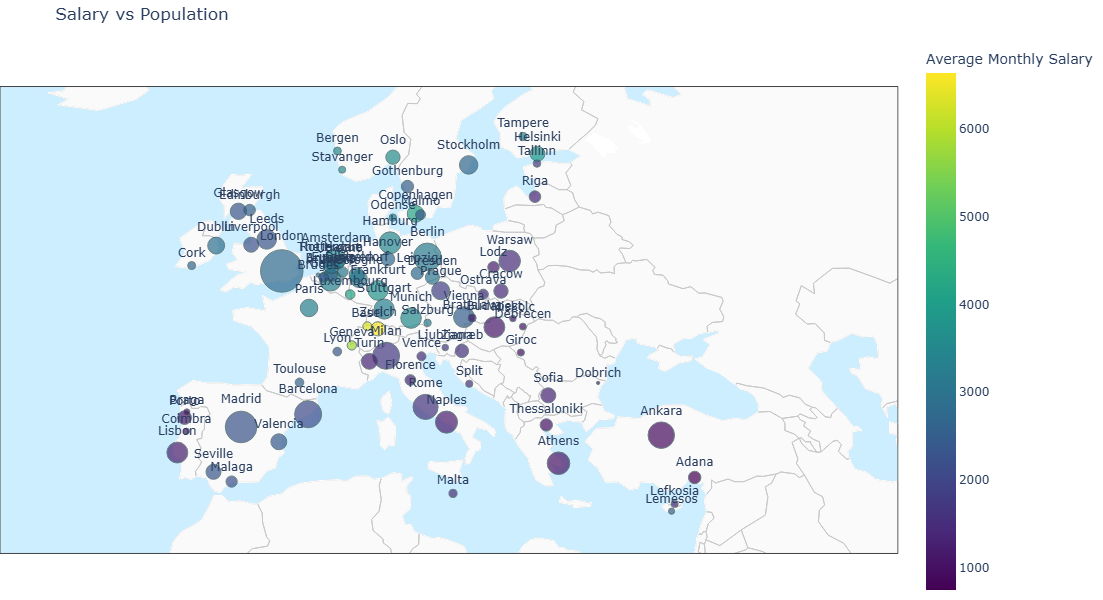

In [64]:
import plotly.express as px

df_map = df.reset_index()

import plotly.express as px

df_map['hover_text'] = df_map.apply(lambda row: (
    f"<b>{row['City']}</b>, {row['Country']}<br>"
    f"Population: {row['Population']:,.0f}<br>"
    f"Average Salary: €{row['Average Monthly Salary']:,.0f}<br>"
    f"Average Cost of Living: €{row['Average Cost of Living']:,.0f}<br>"
    f"Disposable Income: €{row['Disposable_Income']:,.0f}"
), axis=1)

fig = px.scatter_geo(
    df_map,
    lat='Latitude',
    lon='Longitude',
    color='Average Monthly Salary',
    size='Population',
    hover_name='City',
    text='City',
    color_continuous_scale='Viridis', 
    size_max=30,
    scope='world',
    custom_data=['hover_text'] 
)

fig.update_traces(
    hovertemplate="%{customdata[0]}<extra></extra>",
    textposition='top center',
    marker=dict(line=dict(width=1, color='DarkSlateGrey'))
)

fig.update_layout(
    title="Salary vs Population",
    geo=dict(
        projection_scale=5,
        center=dict(lat=48, lon=15),
        showland=True,
        landcolor="rgb(250, 250, 250)",
        showocean=True,
        oceancolor="rgb(204, 238, 255)",
        showcountries=True,
        countrycolor="rgb(200, 200, 200)",
        coastlinecolor="rgb(255, 255, 255)",
        projection_type='natural earth'
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=600
)

fig.show()

### <font color='#0EE071'>5. Data Science In Action </font> <a class="anchor" id="5"></a>
  [Back to TOC](#toc) 

To decide which city best suits our preferences, we decided to build a **recommendation system**. To do this, we thought it was important to implement the **three variables** presented below:

| Variable                | Description                                                                                                                                                                                                 |
|-----------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Traffic Index**     | Index evaluates cities by their average travel time per 10km.          |
| **Health Care Index** | Estimates the overall quality of a healthcare system by evaluating key factors such as medical professionals, equipment, staff, doctors, and costs. It provides an assessment of the healthcare infrastructure, services, and resources available in a specific location. |
| **Crime Index**       | Estimates the overall level of crime in a city or country. It is categorized as follows: Very Low (<20), Low (20-40), Moderate (40-60), High (60-80), Very High (>80).                                                                          |

&nbsp;

#### **Traffic Index**


---


The **Traffic Index** variable was developed by scraping data from the [TomTom Traffic Index ranking](https://www.tomtom.com/traffic-index/ranking/). Specifically, the **average travel time per 10 km** was extracted for each city to serve as a proxy for traffic congestion.

The process involved the following steps:
1.  **Data Extraction:** Raw data was scraped from the website, capturing the travel time in a string format (e.g., "34 min 33 s").
2.  **Data Transformation:** The time strings were parsed and converted into a continuous numerical value (`float`) representing total minutes.
3.  **Integration:** This new variable was merged with the main city dataset based on city names.
4.  **Imputation:** Missing values for cities not covered by the TomTom index were imputed using the **K-Nearest Neighbors (KNN)** algorithm ($k=5$) to ensure data completeness without introducing significant bias.

In [65]:
options = Options()
browser = webdriver.Chrome(options=options)

url = "https://www.tomtom.com/traffic-index/ranking/"
browser.get(url)
time.sleep(5)

try:
    cookie_btn = browser.find_elements(By.CLASS_NAME, "cookie-panel-buttons__accept-all") 
    if cookie_btn:
        cookie_btn[0].click()
        print("Cookies accepted.")
        time.sleep(1)
except:
    print("Cookie button not found or not required.")
    browser.execute_script("window.scrollTo(0, document.body.scrollHeight);")
time.sleep(3)

try:
    metro_btn = browser.find_element(By.CSS_SELECTOR, "button[data-subcomponent-name='tab: Metro area']")
    browser.execute_script("arguments[0].click();", metro_btn)
    print("Metro Area selected.")
    time.sleep(5) 

except Exception as e:
    print(f"Button not found: {e}")

browser.execute_script("window.scrollTo(0, document.body.scrollHeight);")
time.sleep(3)

html_source = browser.page_source
browser.quit()

soupObj = BeautifulSoup(html_source, 'html.parser')

city_elements = soupObj.find_all(class_="sc-ee39d188-0 gZPaPP")
cities_list = []

for element in city_elements:
    full_text = element.get_text(separator="|").strip()
    city_name = full_text.split("|")[0].strip()
    cities_list.append(city_name)

time_elements = soupObj.find_all(class_="sc-e14224e6-5 dfTmKm")
times_list = [time.text.strip() for time in time_elements]

min_len = min(len(cities_list), len(times_list))
cities_list = cities_list[:min_len]
times_list = times_list[:min_len]

df_tomtom = pd.DataFrame({
    'City_TomTom': cities_list,
    'Traffic Index': times_list
})

print('df_tomtom created.')

Cookies accepted.
Metro Area selected.
df_tomtom created.


In [66]:
df_index = df.reset_index()
corr_cities = {
    'gent': 'ghent',
    'lefkosia': 'nicosia',
    'frankfurt': 'frankfurt am main',
    'malta':'valletta',
    'cracow':'krakow',
    'stockholm': 'stockholm metropolitan area'
}

df_index['City_Lower'] = df_index['City'].astype(str).str.lower().str.strip()
df_index['City_Lower'] = df_index['City_Lower'].replace(corr_cities)
df_tomtom['City_Lower'] = df_tomtom['City_TomTom'].astype(str).str.lower().str.strip()
df_tomtom = df_tomtom.drop_duplicates(subset=['City_Lower'], keep='first') #cities from diferent countries with the same name

df_final = pd.merge(df_index, df_tomtom[['City_Lower', 'Traffic Index']], on='City_Lower', how='left')
df_final.drop(columns=['City_Lower'], inplace=True)

In [67]:
df_final[df_final['Traffic Index'].isnull()]

,City,Country,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,...,Average Rent Price,Average Cost of Living,Last Data Update,Main Spoken Languages List,Salary_vs_CostLiv_Diff,Rent_Burden,Disposable_Income,Latitude,Longitude,Traffic Index
7,Dobrich,Bulgaria,640.0,73895,46359.0,22.85,4.6,10089.92,0,"Bulgarian, Turkish",...,400,1100,2023-12-30,"[Bulgarian, Turkish]",100,33.333333,100,43.56700,27.83300,NaN
12,Lemesos,Cyprus,190.0,262238,173906.0,23.06,11.2,34907.00,0,"Greek, English, Russian",...,1400,2300,2023-08-14,"[Greek, English, Russian]",200,56.000000,200,34.67472,33.04417,NaN
24,Hanover,Germany,444.0,1316467,854349.0,21.00,4.0,54827.00,2,German,...,900,1800,2023-10-07,[German],1000,32.142857,1000,52.36700,9.71700,NaN
45,Zagreb,Croatia,240.0,1217131,800501.0,22.70,2.7,38664.00,4,Croatian,...,700,1330,2023-10-14,[Croatian],240,44.585987,240,45.81306,15.97750,NaN
46,Split,Croatia,120.0,354264,230745.0,22.90,6.5,21560.00,1,Croatian,...,600,1250,2023-09-30,[Croatian],250,40.000000,250,43.51000,16.44000,NaN
48,Miskolc,Hungary,172.0,283319,186102.0,24.10,4.4,21805.00,3,Hungarian,...,500,900,2023-11-18,[Hungarian],100,50.000000,100,48.10417,20.79167,NaN
49,Debrecen,Hungary,163.0,328409,219758.0,22.40,4.5,22648.00,7,Hungarian,...,450,950,2024-08-31,[Hungarian],50,45.000000,50,47.53167,21.62444,NaN
57,Venice,Italy,852.0,557748,347781.0,19.30,6.1,39681.00,6,Italian,...,1150,1500,2023-03-23,[Italian],100,82.142857,-100,45.43750,12.33583,NaN
76,Giroc,Romania,1500.0,351851,244969.0,21.20,3.4,34708.00,7,Romanian,...,450,900,2023-08-18,[Romanian],0,50.000000,0,45.70000,21.23300,NaN


In [68]:
def convert_time(value):
    if pd.isna(value) or value == "":
        return None
    min = 0
    match_min = re.search(r'(\d+)\s*min', value)
    if match_min:
        min = int(match_min.group(1))
    sec = 0
    match_sec = re.search(r'(\d+)\s*s', value)
    if match_sec:
        sec = int(match_sec.group(1))
    return min + (sec / 60)

df_final['Traffic Index'] = df_final['Traffic Index'].apply(convert_time)

In [69]:
num_cols = [
    'Population Density', 'Population', 'Working Age Population', 
    'Youth Dependency Ratio', 'Unemployment Rate', 'GDP per Capita', 
    'Average Monthly Salary', 'Average Rent Price', 
    'Average Cost of Living', 'Salary_vs_CostLiv_Diff','Rent_Burden',
    'Disposable_Income','Traffic Index'
]

imputer = KNNImputer(n_neighbors=5)
df_imputed_array = imputer.fit_transform(df_final[num_cols])
df_final[num_cols] = pd.DataFrame(df_imputed_array, columns=num_cols)

In [70]:
df_final['Traffic Index'].isnull().sum()

np.int64(0)

In [71]:
len(df_final['City'].tolist())

84

In [72]:
# Check values assigned with KNN
#idx_nul=[7,12,24,46,47,49,50,58,77]
#df_final.loc[idx_nul, ['City', 'Traffic Index']]

#### **Health Care Index**


---

The **Health Care Index** variable was developed by scraping data from the [Numbeo Health Care Rankings](https://www.numbeo.com/health-care/rankings.jsp). Specifically, the **Health Care Index** score was extracted for each city to serve as a proxy for healthcare quality and accessibility.

The process involved the following steps:

1. **Data Extraction:** Raw data was scraped from the website, capturing city names and index values from the rankings table.
2. **Data Transformation:** City names were cleaned and standardized (lowercase, stripped) for matching, with duplicates removed based on the cleaned city name.
3. **Integration:** The Health Care Index was merged with the main city dataset using the cleaned city name as the key (`left join`).
4. **Imputation:** Missing values were first filled by the country median (when available), then by the global mean to ensure data completeness without significan bias.


In [73]:
def get_numbeo_health_index():
    url = "https://www.numbeo.com/health-care/rankings.jsp"
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 't2'})
    rows = table.find('tbody').find_all('tr')
    data = []
    for row in rows:
        cols = row.find_all('td')
        if len(cols) >= 2:
            full_name = cols[1].get_text(strip=True)
            index_val = float(cols[2].get_text(strip=True))
            parts = full_name.split(',')
            city_clean = parts[0].strip().lower()
            data.append({'City_Numbeo': full_name,
                        'City_Match': city_clean,
                        'Health Care Index': index_val})
    return pd.DataFrame(data)

df_health = get_numbeo_health_index()

if not df_health.empty:
    df_final['City_Match'] = df_final['City'].astype(str).str.lower().str.strip()
    df_health = df_health.drop_duplicates(subset=['City_Match'], keep='first')
    df_final = pd.merge(df_final, df_health[['City_Match', 'Health Care Index']], on='City_Match', how='left')
    df_final.drop(columns=['City_Match'], inplace=True)

else:
    print("No data founded.")

In [74]:
df_final['Health Care Index'].isnull().sum()

np.int64(22)

In [75]:
if 'Country' in df_final.columns:
    df_final['Health Care Index'] = df_final.groupby('Country')['Health Care Index'].transform(lambda x: x.fillna(x.median()))
    global_mean = df_final['Health Care Index'].mean()
    df_final['Health Care Index'] = df_final['Health Care Index'].fillna(global_mean)

else:
    print("'Country' not found.")
    df_final['Health Care Index'] = df_final['Health Care Index'].fillna(df_final['Health Care Index'].mean())

In [76]:
df_final['Health Care Index'].isnull().sum()

np.int64(0)

#### **Crime Index**


---

The **Crime Index** variable was developed by scraping data from the [Numbeo Crime Rankings](https://www.numbeo.com/crime/rankings.jsp). Specifically, the **Crime Index** score was extracted for each city to serve as a proxy for urban safety and crime levels.

The process involved the following steps:

1. **Data Extraction:** Raw data was scraped from the website, capturing city names and crime index values from the rankings table.
2. **Data Transformation:** City names were cleaned and standardized (lowercase, stripped) for matching, with duplicates removed based on the cleaned city name.
3. **Integration:** The Crime Index was merged with the main city dataset using the cleaned city name as the key (`left join`).
4. **Imputation:** Missing values were first filled by the country median (when available), then by the global mean to ensure data completeness without significant bias.

In [77]:
def get_numbeo_crime_index():
    url = "https://www.numbeo.com/crime/rankings.jsp"
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 't2'})
    rows = table.find('tbody').find_all('tr')
    data = []
    for row in rows:
        cols = row.find_all('td')
        if len(cols) >= 2:
            full_name = cols[1].get_text(strip=True)
            index_val = float(cols[2].get_text(strip=True))
            parts = full_name.split(',')
            city_clean = parts[0].strip().lower()
            data.append({'City_Numbeo': full_name,
                        'City_Match': city_clean,
                        'Crime Index': index_val})
    return pd.DataFrame(data)

df_crime = get_numbeo_crime_index()

if not df_crime.empty:
    df_final['City_Match'] = df_final['City'].astype(str).str.lower().str.strip()
    df_crime = df_crime.drop_duplicates(subset=['City_Match'], keep='first')
    df_final = pd.merge(df_final, df_crime[['City_Match', 'Crime Index']], on='City_Match', how='left')
    df_final.drop(columns=['City_Match'], inplace=True)

else:
    print("No data founded.")

In [78]:
df_final['Crime Index'].isnull().sum()

np.int64(19)

In [79]:
if 'Country' in df_final.columns:
    df_final['Crime Index'] = df_final.groupby('Country')['Crime Index'].transform(lambda x: x.fillna(x.median()))
    global_mean = df_final['Crime Index'].mean()
    df_final['Crime Index'] = df_final['Crime Index'].fillna(global_mean)

else:
    print("'Country' not found.")
    df_final['Crime Index'] = df_final['Crime Index'].fillna(df_final['Crime Index'].mean())

In [80]:
df_final['Crime Index'].isnull().sum()

np.int64(0)

#### **Recommendation System** <a class="anchor" id="5_1"></a>


This final section cleans the dataset, exports it for deployment, and automatically generates/launches a **Streamlit web application** for interactive city recommendations.

### Key Steps:
1. **Data Cleaning:** Removes index artifacts like "Unnamed: 0" columns generated by pandas.
2. **Export:** Saves the final clean dataset as `df_final.csv` for the app.
3. **App Generation:** Creates `where_should_i_live.py` with:
   - Weighted scoring system (0-10 sliders for 11+ metrics)
   - Hard constraints/filters (min/max values)
   - Top 5 ranking table + bar chart
   - Radar chart comparison (normalized 0-100%)
   - Podium visualization
4. **Auto-Launch:** Starts Streamlit on `localhost:8502` and opens in browser.

The app uses **percentile ranking** for fair comparisons across metrics (higher=better metrics get boosted, lower=better get inverted), making it intuitive for end-users to find their ideal city.


In [85]:
print("Preparing dashboard...")
print(f"{len(df_final)} cities loaded from notebook.")

if "Unnamed: 0" in df_final.columns:
    df_final = df_final.drop(columns=["Unnamed: 0"])
    print("Removed column 'Unnamed: 0'.")

df_final.to_csv("df_final_clean.csv", index=False)
print("Saved df_final_clean.csv!")

app_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Color palette
C_PRIMARY    = '#2E86C1'
C_SECONDARY  = '#A23B72'
C_POSITIVE   = '#00D2D3'
C_NEGATIVE   = '#FF6B6B'
C_LIGHT_GREY = '#F8F9FA'

st.set_page_config(layout="wide", page_title="Where Should I Live?")

# Basic styling
st.markdown(
    f"""
    <style>
    .main {{
        background-color: #F8FAFF;
    }}
    .block-container {{
        padding-top: 1rem;
        padding-bottom: 2rem;
    }}
    .stMetric label {{
        font-weight: 600;
    }}
    </style>
    """,
    unsafe_allow_html=True,
)

@st.cache_data
def load_data():
    df = pd.read_csv("df_final_clean.csv")
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    if "City" in df.columns:
        df = df.set_index("City")
    return df

df_final = load_data()

st.title("Where Should I Live?")
st.markdown(
    "An interactive dashboard that uses your own dataset to recommend the best cities "
    "based on your priorities."
)

col1, col2, col3 = st.columns(3)
with col1:
    st.metric("Number of cities", len(df_final))
with col2:
    n_countries = df_final["Country"].nunique() if "Country" in df_final.columns else "N/A"
    st.metric("Number of countries", n_countries)
with col3:
    st.metric("Columns available", len(df_final.columns))

@st.cache_data
def recommend_cities(df, weights, constraints=None):
    df_pro = df.copy()

    # Apply hard constraints
    if constraints:
        for col, (typ, val) in constraints.items():
            if col in df_pro.columns:
                if typ == "max":
                    df_pro = df_pro[df_pro[col] <= val]
                elif typ == "min":
                    df_pro = df_pro[df_pro[col] >= val]

    if len(df_pro) == 0:
        return None

    # True = higher is better, False = lower is better
    config = {
        "Average Monthly Salary": True,
        "Salary_vs_CostLiv_Diff": True,   # your net income column
        "GDP per Capita": True,
        "Health Care Index": True,
        "Population": True,
        "Unemployment Rate": False,
        "Average Rent Price": False,
        "Average Cost of Living": False,
        "Crime Index": False,
        "Traffic Index": False,
        "Days of very strong heat stress": False,
    }

    df_pro["score"] = 0.0
    total_weight = sum(weights[col] for col in weights if col in df_pro.columns)

    for col, higher_is_better in config.items():
        if col in df_pro.columns and col in weights and weights[col] > 0:
            rank = df_pro[col].rank(pct=True)
            if not higher_is_better:
                rank = 1 - rank
            df_pro["score"] += rank * weights[col]

    if total_weight > 0:
        df_pro["Match %"] = (df_pro["score"] / total_weight * 100).round(1)
    else:
        df_pro["Match %"] = 0.0

    return df_pro.sort_values("Match %", ascending=False)

st.header("Preference weights (0–10)")

# Variable labels + descriptions – keys MUST match your column names
weight_options = {
    "Salary_vs_CostLiv_Diff": {
        "label": "Disposable Income",
        "desc": "Difference between salary and cost of living (higher = more money left each month).",
    },
    "Crime Index": {
        "label": "Crime index",
        "desc": "Overall crime level in the city (lower = safer).",
    },
    "Health Care Index": {
        "label": "Health care index",
        "desc": "Quality and accessibility of healthcare services (higher = better).",
    },
    "Average Monthly Salary": {
        "label": "Average monthly salary",
        "desc": "Average gross monthly salary in the city (higher = better).",
    },
    "GDP per Capita": {
        "label": "GDP per capita",
        "desc": "Economic development level of the country (higher = wealthier).",
    },
    "Population": {
        "label": "Population",
        "desc": "Total city population (higher = larger city, more services and opportunities).",
    },
    "Unemployment Rate": {
        "label": "Unemployment rate",
        "desc": "Percentage of people without jobs (lower = more job security).",
    },
    "Average Rent Price": {
        "label": "Average rent price",
        "desc": "Average monthly rent (lower = more affordable housing).",
    },
    "Average Cost of Living": {
        "label": "Average cost of living",
        "desc": "Average monthly cost for basic expenses (lower = cheaper to live).",
    },
    "Traffic Index": {
        "label": "Traffic index",
        "desc": "Traffic congestion and travel time (lower = faster commuting).",
    },
    "Days of very strong heat stress": {
        "label": "Very hot days per year",
        "desc": "Number of extremely hot days (lower = more climate comfort).",
    },
}

weights = {}
for col, meta in weight_options.items():
    if col in df_final.columns:
        st.markdown(f"**{meta['label']}**")
        st.caption(meta["desc"])
        weights[col] = st.slider(
            f"Weight for {col}",
            min_value=0,
            max_value=10,
            value=0,
            step=1,
            key=f"w_{col}",
        )

st.header("Hard filters (optional)")

constraint_cols = st.columns(3)
constraints = {}
for idx, (col, meta) in enumerate(weight_options.items()):
    if col in df_final.columns:
        with constraint_cols[idx % 3]:
            choice = st.selectbox(
                f"Filter on {meta['label']}",
                ["None", "Maximum", "Minimum"],
                key=f"filter_{col}",
            )
            if choice != "None":
                mn = float(df_final[col].min())
                mx = float(df_final[col].max())
                default_val = (mn + mx) / 2
                val = st.number_input(
                    f"{choice} allowed for {col}",
                    min_value=mn,
                    max_value=mx,
                    value=default_val,
                    key=f"filter_value_{col}",
                )
                constraints[col] = ("max" if choice == "Maximum" else "min", val)

st.markdown("---")

if st.button("Compute Top 5 cities", type="primary", use_container_width=True):
    result = recommend_cities(df_final, weights, constraints)

    if result is not None and len(result) > 0:
        st.success("Top 5 cities calculated based on your preferences.")

        # ---- Top 5 table ----
        top5 = result[["Country", "Match %"]].head(5)
        top5.index.name = "City"

        st.subheader("Top 5 cities")
        st.dataframe(
            top5.style.format({"Match %": "{:.1f}%"}),
            use_container_width=True,
        )

        top5_plot = result.head(5).reset_index()  # City, Country, Match %

        # ---- Podium ----
        st.subheader("Podium")
        c1, c2, c3 = st.columns(3)
        c1.metric("1st", top5_plot.iloc[0]["City"], f"{top5_plot.iloc[0]['Match %']:.1f}%")
        if len(top5_plot) > 1:
            c2.metric("2nd", top5_plot.iloc[1]["City"], f"{top5_plot.iloc[1]['Match %']:.1f}%")
        if len(top5_plot) > 2:
            c3.metric("3rd", top5_plot.iloc[2]["City"], f"{top5_plot.iloc[2]['Match %']:.1f}%")

        # ---- Chart 1: Overall match ranking ----
        st.subheader("Overall suitability score (%)")
        fig1 = px.bar(
            top5_plot,
            x="Match %",
            y="City",
            orientation="h",
            color="Match %",
            text="Match %",
            color_continuous_scale=[C_NEGATIVE, C_SECONDARY, C_POSITIVE],
        )
        fig1.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
        fig1.update_layout(
            xaxis_title="Match to your preferences (%)",
            yaxis_title="City",
            height=400,
            plot_bgcolor="white",
        )
        st.plotly_chart(fig1, use_container_width=True)

        # ---- Chart 2: Economic comparison ----
        economic_cols = [
            "Average Monthly Salary",
            "Average Cost of Living",
            "Average Rent Price",
            "Salary_vs_CostLiv_Diff",
        ]
        available_econ = [c for c in economic_cols if c in df_final.columns]
        if available_econ:
            st.subheader("Economic profile of Top 5 cities")
            econ = top5_plot[["City"] + available_econ].melt(
                id_vars="City", var_name="Metric", value_name="Value"
            )
            econ_palette = {
                "Average Monthly Salary": C_PRIMARY,
                "Average Cost of Living": C_NEGATIVE,
                "Average Rent Price": C_SECONDARY,
                "Salary_vs_CostLiv_Diff": C_POSITIVE,
            }
            fig2 = px.bar(
                econ,
                x="City",
                y="Value",
                color="Metric",
                barmode="group",
                color_discrete_map=econ_palette,
            )
            fig2.update_layout(
                xaxis_title="City",
                yaxis_title="Amount (same currency as your dataset)",
                height=450,
                plot_bgcolor="white",
            )
            st.plotly_chart(fig2, use_container_width=True)

        # ---- Chart 3: Safety & mobility ----
        risk_cols = ["Crime Index", "Unemployment Rate", "Traffic Index"]
        available_risk = [c for c in risk_cols if c in df_final.columns]
        if available_risk:
            st.subheader("Safety and mobility indicators")
            risk = top5_plot[["City"] + available_risk].melt(
                id_vars="City", var_name="Metric", value_name="Value"
            )
            risk_palette = {
                "Crime Index": C_NEGATIVE,
                "Unemployment Rate": C_SECONDARY,
                "Traffic Index": C_LIGHT_GREY,
            }
            fig3 = px.bar(
                risk,
                x="City",
                y="Value",
                color="Metric",
                barmode="group",
                color_discrete_map=risk_palette,
            )
            fig3.update_layout(
                xaxis_title="City",
                yaxis_title="Index / percentage (original units)",
                height=450,
                plot_bgcolor="white",
            )
            st.plotly_chart(fig3, use_container_width=True)

        # ---- Chart 4: Radar across active metrics ----
        active_cols = [
            c for c in weight_options
            if c in df_final.columns and weights.get(c, 0) > 0
        ]
        if len(active_cols) >= 3:
            st.subheader("Normalized comparison across active criteria (0–100%)")

            top5_radar = top5_plot[["City"] + active_cols].copy()

            config_for_radar = {
                "Average Monthly Salary": True,
                "Salary_vs_CostLiv_Diff": True,
                "GDP per Capita": True,
                "Health Care Index": True,
                "Population": True,
                "Unemployment Rate": False,
                "Average Rent Price": False,
                "Average Cost of Living": False,
                "Crime Index": False,
                "Traffic Index": False,
                "Days of very strong heat stress": False,
            }

            for col in active_cols:
                higher_is_better = config_for_radar.get(col, True)
                ranks = top5_radar[col].rank(pct=True)
                if not higher_is_better:
                    ranks = 1 - ranks
                top5_radar[col] = (ranks * 100).round(1)

            fig_r = go.Figure()
            radar_colors = [C_PRIMARY, C_SECONDARY, C_POSITIVE, C_NEGATIVE, "#74B9FF"]
            for i, (_, row) in enumerate(top5_radar.iterrows()):
                fig_r.add_trace(
                    go.Scatterpolar(
                        r=[row[c] for c in active_cols],
                        theta=active_cols,
                        fill="toself",
                        name=row["City"],
                        line_color=radar_colors[i % len(radar_colors)],
                    )
                )

            fig_r.update_layout(
                polar=dict(
                    radialaxis=dict(range=[0, 100], tickvals=[0, 25, 50, 75, 100])
                ),
                showlegend=True,
                height=500,
                plot_bgcolor="white",
            )
            st.plotly_chart(fig_r, use_container_width=True)

    else:
        st.warning("No city satisfies your filters. Try relaxing some constraints or weights.")
'''

with open("where_should_i_live.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("where_should_i_live.py written.")

def launch_app():
    subprocess.Popen(
        ["streamlit", "run", "where_should_i_live.py", "--server.headless", "true", "--server.port", "8502"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
    )

thread = threading.Thread(target=launch_app, daemon=True)
thread.start()

time.sleep(3)
webbrowser.open("http://localhost:8502")
print("Dashboard opened at http://localhost:8502")

Preparing dashboard...
84 cities loaded from notebook.
Saved df_final_clean.csv!
where_should_i_live.py written.
Dashboard opened at http://localhost:8502
